## Import the required libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs    #make_blobs is used to generate data
from sklearn.preprocessing import StandardScaler

# Load and preprocess the dataset

In [ ]:
# Generate a synthetic dataset with 300 samples and 2 features
data = make_blobs(n_samples=300, centers=4, n_features=2, random_state=42)

# Standardize the dataset
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data[0])

print(data_scaled[:10])     #printing the first 10 rows of dataset

[[-1.11618972  0.58377179]
 [-1.19214185  0.65863295]
 [ 0.32520384  0.79611099]
 [-0.6994772  -1.38795911]
 [-1.4151792   0.55831196]
 [-0.49582696 -1.5904761 ]
 [ 1.55613267 -0.0783288 ]
 [-0.58005049 -1.65544196]
 [ 0.0786816   0.96266372]
 [ 1.29772382 -0.03468911]]


# Implement the K-means algorithm

In [ ]:
def initialize_centroids(data, k):
    """Randomly initialize the centroids from the data points."""
    np.random.seed(42)
    random_indices = np.random.choice(data.shape[0], size=k, replace=False)
    centroids = data[random_indices]
    print("  Inside initialize_centroids: Initialized centroids (first 5 rows):\n", centroids[:5])
    return centroids

def compute_distances(data, centroids):
    """Compute the distances between each data point and centroids."""
    distances = np.zeros((data.shape[0], centroids.shape[0]))
    for i, centroid in enumerate(centroids):
        distances[:, i] = np.linalg.norm(data - centroid, axis=1)
    print("  Inside compute_distances: Distances shape:", distances.shape)
    print("  Inside compute_distances: First 5 rows of distances:\n", distances[:5])
    return distances

def assign_clusters(distances):
    """Assign each data point to the closest centroid."""
    # Hint: np.argmin to find the index of the minimum value along an axis
    clusters = np.argmin(distances, axis=1)
    print("  Inside assign_clusters: First 10 cluster assignments:", clusters[:10])
    return clusters

def update_centroids(data, clusters, k):
    """Update the centroids by computing the mean of the points in each cluster."""
    new_centroids = np.zeros((k, data.shape[1]))
    for i in range(k):
        cluster_points = data[clusters == i]
        if len(cluster_points) > 0:
            # Find the average of all points in this cluster to get the new center (centroid)
            new_centroids[i] = np.mean(cluster_points, axis=0)
    print("  Inside update_centroids: Updated centroids (first 5 rows):\n", new_centroids[:5])
    return new_centroids

def k_means(data, k, max_iterations=100):
    """Implement the K-means clustering algorithm."""
    print("Inside k_means: Starting K-means algorithm with k=", k)
    centroids = initialize_centroids(data, k)
    for i in range(max_iterations):
        print(f"  Inside k_means: Iteration {i + 1}/")
        # Step 1: Compute distances from data points to centroids
        distances = compute_distances(data, centroids)

        # Step 2: Assign clusters
        clusters = assign_clusters(distances)

        # Step 3: Update centroids
        new_centroids = update_centroids(data, clusters, k)

        # Step 4: Check for convergence
        if np.allclose(centroids, new_centroids):
            print(f"  Inside k_means: Converged at iteration {i + 1}.")
            break

        centroids = new_centroids
    print("Inside k_means: K-means algorithm finished.")
    return centroids, clusters

# Evaluate the results

In [ ]:
# Choose the number of clusters, K
k = 4

# Run the K-means algorithm
centroids, clusters = k_means(data_scaled, k)

# Compute the total within-cluster sum of squares
wcss = np.sum([np.sum(np.square(data_scaled[clusters == i] - centroids[i])) for i in range(k)])
print("Total within-cluster sum of squares: ", wcss)

Inside k_means: Starting K-means algorithm with k= 4
  Inside initialize_centroids: Initialized centroids (first 5 rows):
 [[ 1.41172021 -0.00362919]
 [-0.63547046 -1.48197431]
 [ 1.57655013 -0.24051046]
 [ 1.29772382 -0.03468911]]
  Inside k_means: Iteration 1/
  Inside compute_distances: Distances shape: (300, 4)
  Inside compute_distances: First 5 rows of distances:
 [[2.59525885 2.1209427  2.8160769  2.49188131]
 [2.68676177 2.21180525 2.91103318 2.58459408]
 [1.34911163 2.47236076 1.62494664 1.27907152]
 [2.52458389 0.11373531 2.54890934 2.41249904]
 [2.88221064 2.18419636 3.09654027 2.77695752]]
  Inside assign_clusters: First 10 cluster assignments: [1 1 3 1 1 1 0 1 3 3]
  Inside update_centroids: Updated centroids (first 5 rows):
 [[ 1.50866258  0.01562357]
 [-0.84204937 -0.53503739]
 [ 1.66002088 -0.21442088]
 [ 0.20717674  0.81133097]]
  Inside k_means: Iteration 2/
  Inside compute_distances: Distances shape: (300, 4)
  Inside compute_distances: First 5 rows of distances:
 [

# Visualize the clusters

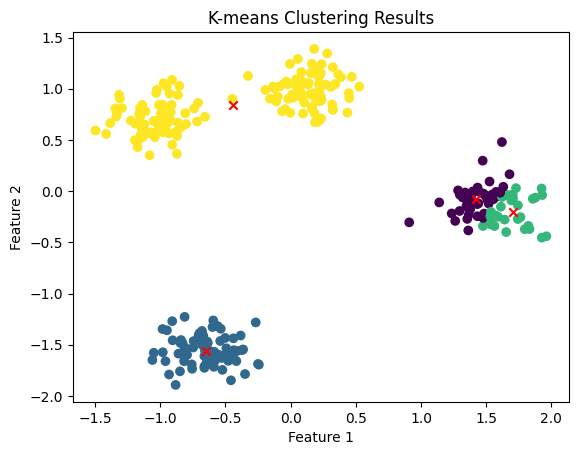

In [ ]:
# Plot the dataset with the assigned clusters and centroids
plt.scatter(data_scaled[:, 0], data_scaled[:, 1], c=clusters, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-means Clustering Results')
plt.show()

In [ ]:
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Add the target column (species)
iris_df['species'] = iris.target

# Drop the 'species' column for unsupervised clustering
iris_df_processed = iris_df.drop(columns=['species'])

print("Original Iris DataFrame head with species:")
print(iris_df.head())
print("\nProcessed Iris DataFrame head without species:")
print(iris_df_processed.head())

Original Iris DataFrame head with species:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  

Processed Iris DataFrame head without species:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1              

In [ ]:
from sklearn.cluster import KMeans

# Instantiate KMeans with n_clusters=2 and random_state for reproducibility
kmeans_model_k2 = KMeans(n_clusters=2, random_state=42, n_init=10)

# Fit the model to the preprocessed Iris dataset
kmeans_model_k2.fit(iris_df_processed)

# Predict the cluster labels
clusters_k2 = kmeans_model_k2.predict(iris_df_processed)

# Add the cluster labels to the DataFrame
iris_df_processed['cluster_k2'] = clusters_k2

print("Iris DataFrame with K-Means (k=2) cluster assignments (first 5 rows):")
print(iris_df_processed.head())

Iris DataFrame with K-Means (k=2) cluster assignments (first 5 rows):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   cluster_k2  
0           1  
1           1  
2           1  
3           1  
4           1  


In [ ]:
inertia_values = []

# Define a range of K values to test
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(iris_df_processed.drop(columns=['cluster_k2'], errors='ignore'))
    inertia_values.append(kmeans.inertia_)

print("Inertia values for K from 1 to 10:", inertia_values)

Inertia values for K from 1 to 10: [777.5306, 247.63174868702592, 78.851441426146, 59.34876557610241, 46.985061122661115, 39.57886631746632, 35.461553571428574, 31.690262769093668, 28.942833517617586, 27.09982615831023]


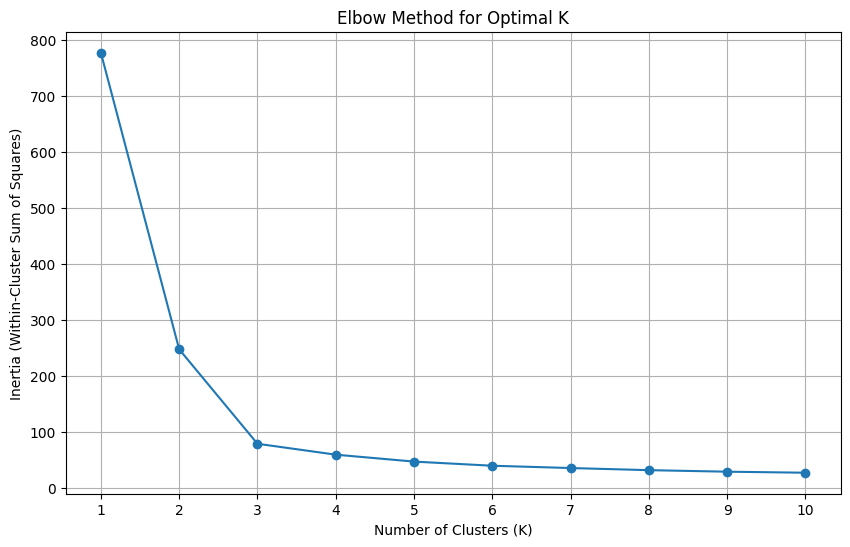

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal K')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [ ]:
from sklearn.cluster import KMeans

# Drop the 'cluster_k2' column before applying K-Means with the optimal K
iris_df_processed = iris_df_processed.drop(columns=['cluster_k2'], errors='ignore')

# Instantiate KMeans with the optimal K (3) and random_state for reproducibility
k_optimal = 3
kmeans_optimal = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)

# Fit the model to the preprocessed Iris dataset
kmeans_optimal.fit(iris_df_processed)

# Predict the cluster labels
final_clusters = kmeans_optimal.predict(iris_df_processed)

# Add the final cluster labels to the DataFrame
iris_df_processed['final_cluster'] = final_clusters

print(f"Iris DataFrame with K-Means (k={k_optimal}) final cluster assignments (first 5 rows):\n")
print(iris_df_processed.head())

Iris DataFrame with K-Means (k=3) final cluster assignments (first 5 rows):

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   final_cluster  
0              1  
1              1  
2              1  
3              1  
4              1  


In [ ]:
print("Iris DataFrame with K-Means (k=3) final cluster assignments (first 10 rows):\n")
print(iris_df_processed.head(10))

Iris DataFrame with K-Means (k=3) final cluster assignments (first 10 rows):

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

   final_cluster  
0              1  
1             

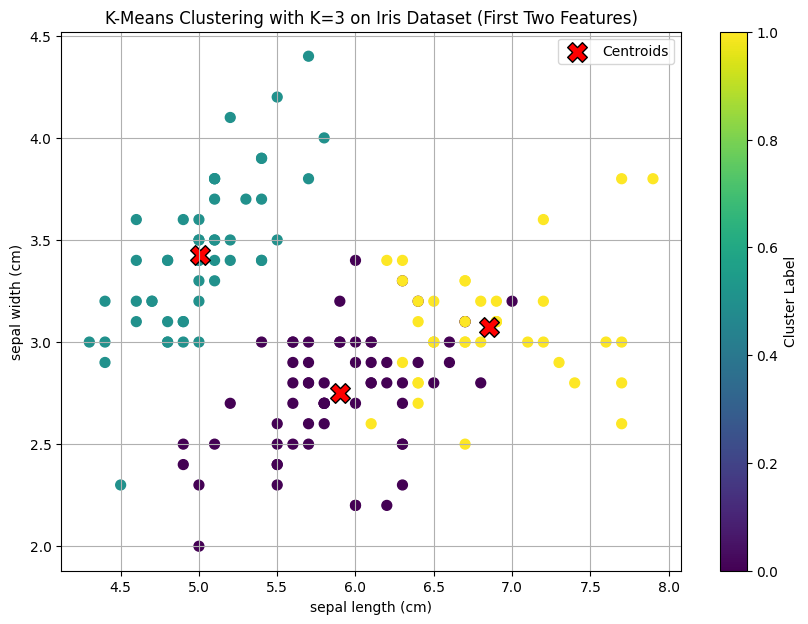

In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(iris_df_processed.iloc[:, 0], iris_df_processed.iloc[:, 1], c=iris_df_processed['final_cluster'], cmap='viridis', s=50)

# Add centroids to the plot
plt.scatter(kmeans_optimal.cluster_centers_[:, 0], kmeans_optimal.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='Centroids', edgecolor='black')

plt.xlabel(iris_df_processed.columns[0])
plt.ylabel(iris_df_processed.columns[1])
plt.title(f'K-Means Clustering with K={k_optimal} on Iris Dataset (First Two Features)')
plt.colorbar(label='Cluster Label')
plt.legend()
plt.grid(True)
plt.show()